In [1]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import pandas as pd
import os
from scipy.ndimage import label
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score

In [2]:
def resample_to_reference(input_tif, reference_tif, output_tif, resampling_method=Resampling.bilinear):
    """
    Resample input_tif so it matches the grid of reference_tif.
    Saves the aligned raster to output_tif.
    """
    with rasterio.open(reference_tif) as ref:
        ref_transform = ref.transform
        ref_crs = ref.crs
        ref_height = ref.height
        ref_width = ref.width

        with rasterio.open(input_tif) as src:
            src_data = src.read(1)

            destination = np.empty((ref_height, ref_width), dtype=np.float32)

            reproject(
                source=src_data,
                destination=destination,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=ref_transform,
                dst_crs=ref_crs,
                resampling=resampling_method
            )

            profile = ref.profile.copy()
            profile.update(dtype="float32", count=1, nodata=np.nan)

            with rasterio.open(output_tif, "w", **profile) as dst:
                dst.write(destination, 1)

In [4]:
input_folder = "../Karte"
output_folder = "../Karte_jedna_mreza"
os.makedirs(output_folder, exist_ok=True)
tif_files = [f for f in os.listdir(input_folder) if f.endswith(".tif") and not f.startswith("NE")]
reference_file = tif_files[0]
input_reference_path = os.path.join(input_folder, reference_file)
output_reference_path = os.path.join(output_folder, reference_file)
tif_files

['Prolece_padavine_Srbija.tif',
 'Temp_decembar_1961_2010_Srbija_reprojektovano.tif',
 'Oktobar_padavine_Srbija.tif',
 'Temp_septembar_1961_2010_Srbija_reprojektovano.tif',
 'Temp_god_1961_2010_Srbija_reprojektovano.tif',
 'Novembar_padavine_Srbija.tif',
 'Leto_padavine_Srbija.tif',
 'Temp_leto_1961_2010_Srbija_reprojektovano.tif',
 'Juli_padavine_Srbija.tif',
 'Avgust_padavine_Srbija.tif',
 'April_padavine_bez_granice.tif',
 'Temp_avgust_1961_2010_Srbija_reprojektovano.tif',
 'Temp_juli_1961_2010_Srbija_reprojektovano.tif',
 'Zima_padavine_Srbija.tif',
 'Jesen_padavine_Srbija.tif',
 'Maj_padavine_Srbija.tif',
 'Temp_april_1961_2010_Srbija_reprojektovano.tif',
 'Temp_juni_1961_2010_Srbija_reprojektovano.tif',
 'Temp_maj_1961_2010_Srbija_reprojektovano.tif',
 'Temp_januar_1961_2010_Srbija_reprojektovano.tif',
 'Februar_padavine_Srbija.tif',
 'Temp_novembar_1961_2010_Srbija_reprojektovano.tif',
 'Septembar_padavine_Srbija.tif',
 'Mart_padavine_Srbija.tif',
 'Temp_zima_1961_2010_Srbija.ti

In [4]:
for tif in tif_files:
    input_path = os.path.join(input_folder, tif)
    output_path = os.path.join(output_folder, tif)
    
    if tif == os.path.basename(reference_file):
        # Copy reference raster as-is
        with rasterio.open(input_path) as src:
            data = src.read(1)
            profile = src.profile
            with rasterio.open(output_path, "w", **profile) as dst:
                dst.write(data, 1)
    else:
        resample_to_reference(input_path, output_reference_path, output_path)

In [5]:
with rasterio.open(output_reference_path) as src:
    ref_arr = src.read(1)
    height, width = ref_arr.shape
    transform = src.transform
    crs = src.crs

In [6]:
rows, cols = np.indices((height, width))
xs, ys = rasterio.transform.xy(transform, rows, cols)

xs = np.array(xs)
ys = np.array(ys)

In [7]:
master_df = pd.DataFrame({
    "row": rows.ravel(),
    "col": cols.ravel(),
    "easting": xs.ravel(),
    "northing": ys.ravel()
})
for tif in tif_files:
    var_name = os.path.splitext(os.path.basename(tif))[0]
    output_path = os.path.join(output_folder, tif)
    with rasterio.open(output_path) as src:
        arr = src.read(1).astype("float32")
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
        master_df[var_name] = arr.ravel()

In [8]:
climate_cols = [c for c in master_df.columns if c not in ["row", "col", "easting", "northing"]]
df_valid = master_df.dropna(subset=climate_cols).copy()

In [9]:
print("Total cells:", len(master_df))
print("Valid cells:", len(df_valid))
print("Climate columns:", len(climate_cols))

Total cells: 553539
Valid cells: 301394
Climate columns: 31


In [10]:
master_df.to_csv("master_df.csv")
df_valid.to_csv("df_valid.csv")

/opt/homebrew/lib/python3.8/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


File: NE_Klimati sa reljefnom podlogom_Karta Srbije.tif
Driver: GTiff
Size: 1382 x 2007
Bands: 4
CRS: None
Bounds: BoundingBox(left=0.0, bottom=2007.0, right=1382.0, top=0.0)
Transform: | 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|
Dtypes: ('uint8', 'uint8', 'uint8', 'uint8')
NoData: None


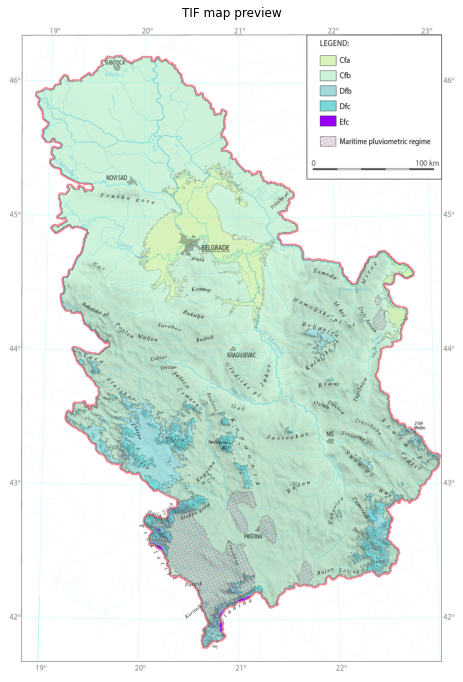


Band 1
  min: 0.0
  max: 255.0
  mean: 220.8208927941784
  std: 42.53446409614153

Band 2
  min: 0.0
  max: 255.0
  mean: 235.98324532731675
  std: 33.25568186536011

Band 3
  min: 0.0
  max: 255.0
  mean: 227.22735584643328
  std: 36.24674776656926

Band 4
  min: 255.0
  max: 255.0
  mean: 255.0
  std: 0.0

Dominant colors / possible map classes:
RGB (190, 224, 202)  count=30844
RGB (204, 240, 218)  count=30618
RGB (177, 207, 187)  count=11647
RGB (160, 222, 216)  count=5540
RGB (216, 240, 186)  count=4724
RGB (145, 170, 160)  count=4536
RGB (125, 208, 210)  count=3817
RGB (109, 136, 131)  count=3254
RGB (249, 129, 143)  count=2220
RGB (77, 82, 80)  count=1521
RGB (30, 31, 31)  count=914
RGB (201, 29, 245)  count=365


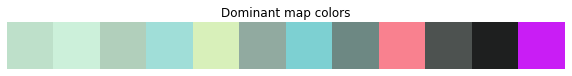

In [4]:
# pip install rasterio matplotlib numpy pillow scikit-learn

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
from sklearn.cluster import KMeans

tif_path = Path("../Karte/NE_Klimati sa reljefnom podlogom_Karta Srbije.tif")

with rasterio.open(tif_path) as src:
    print("File:", tif_path.name)
    print("Driver:", src.driver)
    print("Size:", src.width, "x", src.height)
    print("Bands:", src.count)
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    print("Transform:", src.transform)
    print("Dtypes:", src.dtypes)
    print("NoData:", src.nodata)

    data = src.read()  # shape: bands, height, width

# Display map
if data.shape[0] >= 3:
    rgb = np.stack([data[0], data[1], data[2]], axis=-1)

    # Normalize if needed
    rgb = rgb.astype(float)
    if rgb.max() > 255:
        rgb = 255 * (rgb - rgb.min()) / (rgb.max() - rgb.min())
    rgb = rgb.astype(np.uint8)

    plt.figure(figsize=(12, 12))
    plt.imshow(rgb)
    plt.title("TIF map preview")
    plt.axis("off")
    plt.show()
else:
    plt.figure(figsize=(12, 12))
    plt.imshow(data[0], cmap="terrain")
    plt.title("Single-band TIF preview")
    plt.axis("off")
    plt.colorbar()
    plt.show()

# Basic band statistics
for i, band in enumerate(data, start=1):
    arr = band.astype(float)
    print(f"\nBand {i}")
    print("  min:", np.nanmin(arr))
    print("  max:", np.nanmax(arr))
    print("  mean:", np.nanmean(arr))
    print("  std:", np.nanstd(arr))

# Find dominant colors/classes for RGB maps
if data.shape[0] >= 3:
    pixels = rgb.reshape(-1, 3)

    # Remove near-white background if present
    mask = np.mean(pixels, axis=1) < 245
    sampled = pixels[mask]

    if len(sampled) > 100_000:
        sampled = sampled[np.random.choice(len(sampled), 100_000, replace=False)]

    k = 12
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(sampled)
    colors = kmeans.cluster_centers_.astype(int)
    counts = np.bincount(labels)

    order = np.argsort(counts)[::-1]

    print("\nDominant colors / possible map classes:")
    for idx in order:
        print(f"RGB {tuple(colors[idx])}  count={counts[idx]}")

    # Show palette
    palette = colors[order].reshape(1, k, 3)

    plt.figure(figsize=(10, 2))
    plt.imshow(palette)
    plt.title("Dominant map colors")
    plt.axis("off")
    plt.show()

In [5]:
import rasterio

with rasterio.open("../Karte_jedna_mreza/Zima_padavine_Srbija.tif") as src:
    print("CRS:", src.crs)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Resolution:", src.res)
    print("Bounds:", src.bounds)

CRS: EPSG:32634
Width: 613
Height: 903
Resolution: (542.2193018057923, 542.182254460371)
Bounds: BoundingBox(left=330565.4375209369, bottom=4626298.997080128, right=662945.8695278876, top=5115889.572857843)
